# Breast Cancer Subtype Prediction
# Step 4: Feature Selection - Phase 2 (ANOVA / F-test)
# Goal: Select top 500 features for RNA and Methylation based on statistical significance.

## Import Libraries

In [8]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("✅ Libraries Imported.")

✅ Libraries Imported.


## Define IO Functions

In [9]:
io_dir = '../outputs'

def load_object(filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'rb') as f:
        return pickle.load(f)

def save_object(obj, filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    print(f"💾 Saved: {file_path}")

print("✅ IO Functions Ready.")

✅ IO Functions Ready.


## Load Data (From Step 1 - Variance Threshold)


In [10]:
print("Loading variance-filtered data from '../outputs/'...")

try:
    
    X_train_rna = load_object('X_train_rna_var')
    X_test_rna = load_object('X_test_rna_var')
    feat_indices_rna_var = load_object('feat_indices_rna_var')  
    
   
    X_train_meth = load_object('X_train_meth_var')
    X_test_meth = load_object('X_test_meth_var')
    feat_indices_meth_var = load_object('feat_indices_meth_var')
    
    
    y_train = load_object('y_train')
    y_test = load_object('y_test')
    
    print("\nData Loaded Successfully.")
    print(f"RNA Inputs: {X_train_rna.shape}")
    print(f"Methylation Inputs: {X_train_meth.shape}")
except FileNotFoundError:
    print("❌ Error: Files not found. Run Feature Selection Step 1 first.")

Loading variance-filtered data from '../outputs/'...

Data Loaded Successfully.
RNA Inputs: (439, 48)
Methylation Inputs: (439, 20106)


## 1. ANOVA on RNA-Seq


In [11]:
K_RNA = 500

print(f"Selecting Top {K_RNA} RNA Features using ANOVA...")

selector_rna = SelectKBest(score_func=f_classif, k=K_RNA)

X_train_rna_anova = selector_rna.fit_transform(X_train_rna, y_train)
X_test_rna_anova = selector_rna.transform(X_test_rna)

selected_indices_local = selector_rna.get_support(indices=True)
final_rna_indices = feat_indices_rna_var[selected_indices_local]

print(f"✅ RNA Selection Done. Shape: {X_train_rna_anova.shape}")

Selecting Top 500 RNA Features using ANOVA...
✅ RNA Selection Done. Shape: (439, 48)


c:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=500 is greater than n_features=48. All the features will be returned.
  warnings.warn(


## 2. ANOVA on Methylation


In [12]:
K_METH = 500

print(f"Selecting Top {K_METH} Methylation Features using ANOVA...")

selector_meth = SelectKBest(score_func=f_classif, k=K_METH)

X_train_meth_anova = selector_meth.fit_transform(X_train_meth, y_train)
X_test_meth_anova = selector_meth.transform(X_test_meth)

selected_indices_local_meth = selector_meth.get_support(indices=True)
final_meth_indices = feat_indices_meth_var[selected_indices_local_meth]

print(f"✅ Methylation Selection Done. Shape: {X_train_meth_anova.shape}")

Selecting Top 500 Methylation Features using ANOVA...
✅ Methylation Selection Done. Shape: (439, 500)


## Validation: LDA with Top 1000 Features


Validating with Linear Discriminant Analysis (LDA)...



Classification Report (ANOVA Selected Features):
              precision    recall  f1-score   support

        LumA       0.76      0.66      0.71        59
        LumB       0.37      0.52      0.43        25
        Her2       0.57      0.57      0.57         7
       Basal       1.00      0.89      0.94        19

    accuracy                           0.66       110
   macro avg       0.68      0.66      0.66       110
weighted avg       0.70      0.66      0.68       110



<Figure size 600x600 with 0 Axes>

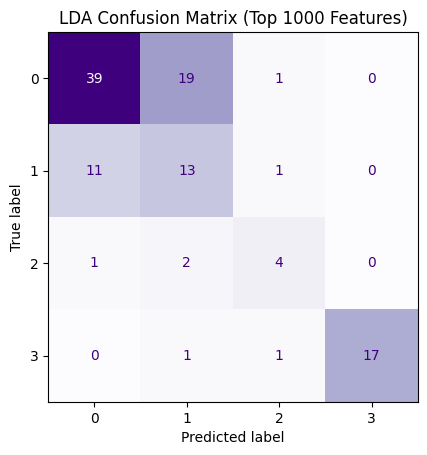

In [13]:
print("Validating with Linear Discriminant Analysis (LDA)...")

X_train_combined = np.hstack((X_train_rna_anova, X_train_meth_anova))
X_test_combined = np.hstack((X_test_rna_anova, X_test_meth_anova))

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_combined, y_train)

y_pred = lda.predict(X_test_combined)

print("\nClassification Report (ANOVA Selected Features):")
print(classification_report(y_test, y_pred, target_names=['LumA', 'LumB', 'Her2', 'Basal']))

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Purples', colorbar=False)
plt.title(f"LDA Confusion Matrix (Top {K_RNA+K_METH} Features)")
plt.show()

## Saving Result


In [ ]:
print("Saving ANOVA selected datasets to '../outputs/'...")

save_object(X_train_rna_anova, 'X_train_rna_anova')
save_object(X_test_rna_anova,  'X_test_rna_anova')
save_object(final_rna_indices, 'feat_indices_rna_anova')

save_object(X_train_meth_anova, 'X_train_meth_anova')
save_object(X_test_meth_anova,  'X_test_meth_anova')
save_object(final_meth_indices, 'feat_indices_meth_anova')


save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print("\n🎉 Feature Selection Step 2 (ANOVA) Completed.")

Saving ANOVA selected datasets to '../outputs/'...
💾 Saved: ../outputs\X_train_rna_anova.pkl
💾 Saved: ../outputs\X_test_rna_anova.pkl
💾 Saved: ../outputs\feat_indices_rna_anova.pkl
💾 Saved: ../outputs\X_train_meth_anova.pkl
💾 Saved: ../outputs\X_test_meth_anova.pkl
💾 Saved: ../outputs\feat_indices_meth_anova.pkl
💾 Saved: ../outputs\y_train.pkl
💾 Saved: ../outputs\y_test.pkl

🎉 Feature Selection Step 2 (ANOVA) Completed.
